In [28]:
import numpy as np
from tqdm import tqdm
import scipy
from matplotlib import pyplot as plt

In [29]:
# Numerov propagation
# Remember: always integrate from classically forbidden to allowed!
def numerov_propagate(V, x_start, x_end, dx, E, m, hbar, psi_0=0.0, psi_1=1e-6, stop_at_peak = False):
    # Set dx negative if necessary
    if x_start > x_end: # integrating backwards
        dx = -np.abs(dx)
    # Create grid
    x = np.arange(x_start, x_end, dx)
    
    # Initialize wavefunction array
    psi = np.zeros(len(x))
    psi[0] = psi_0
    psi[1] = psi_1
    
    factor = 2 * m / (hbar**2)
    
    # Pre-calculate f(x) for the entire grid
    f = factor * (V(x) - E)
    
    for i in range(1, len(x) - 1):
        term1 = 2 * psi[i  ] * (1 + 5 * ((dx**2) / 12.0) * f[i  ])
        term2 =     psi[i-1] * (1 -     ((dx**2) / 12.0) * f[i-1])

        denom =                 1 -     ((dx**2) / 12.0) * f[i+1]
        
        psi[i+1] = (term1 - term2) / denom

        # If psi gets too big, scale it down to avoid numerical issues.
        if np.abs(psi[i]) > 1.0e+3:
            psi /= np.abs(psi[i])

        # If we start integrating into the classically forbidden region from the allowed, stop!
        if (f[i-1] <= 0) and (f[i] >= 0):
            # truncate the results
            x   =   x[0:i]
            psi = psi[0:i]
            break

        # Check if we're at a peak if the option is enabled
        if stop_at_peak:
            if np.abs(psi[i]) < np.abs(psi[i-1]):
                # truncate the results
                x   =   x[0:i]
                psi = psi[0:i]
                break
        
    return x, psi

In [30]:
# Corrected trapezoidal rule numerical integration
def cor_trapz(x, f):
    # Only works with uniform grid!
    h = np.abs(x[1] - x[0])
    return h * (np.sum(f[1:-1]) + 0.5 * (f[0] + f[-1]))

Verifying normalization: (1 - np.trapezoid) gives            1.1e-16


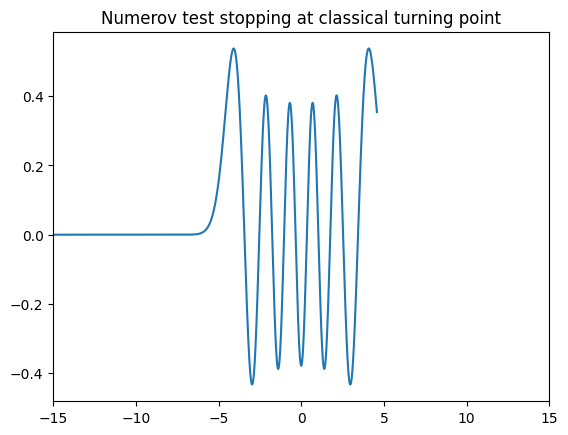

In [31]:
# physical constants
hbar = 1.0
m    = 1.0
w    = 1.0

# harmonic potential
V = lambda x : m*(w**2)*(x**2) / 2.0

# test to make sure the Numerov propagation is working, with the known energy
n = 10
E = hbar * w * (n + 0.5)

# Only go to the known classical turning point to avoid integrating INTO the forbidden region
x_start = -15.0
# x_end   = np.sqrt(2.0*E / (m*(w**2)))
x_end = 15.0
dx = 1.0e-2

# Numerov
x, psi = numerov_propagate(V, x_start, x_end, dx, E, m, hbar)
# Normalize psi
psi *= 1.0 / np.sqrt(cor_trapz(x, np.abs(psi)**2))

fig, ax = plt.subplots()
ax.plot(x, psi)
ax.set_xlim([x_start, x_end])
ax.set_title("Numerov test stopping at classical turning point")

print(f"Verifying normalization: (1 - np.trapezoid) gives\
            {(1.0 - np.trapezoid(np.abs(psi)**2, x=x)):3.1e}")

Matching at x = -0.4400
Wronskian at the matching point: -3.753e+03


Text(0.5, 1.0, 'Numerov test stopping at first peak')

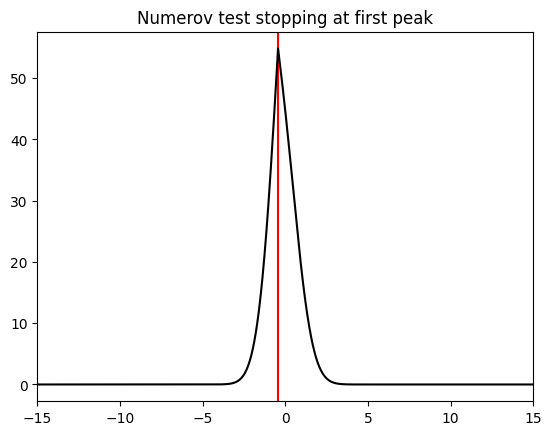

In [32]:
# test to make sure the Numerov propagation is working, with the known energy
n = 10
# E = hbar * w * (n + 0.5)
E = 0.1

# Integrate until peak from other side:
bounds = [-15.0, 15.0]
dx = 0.01

# Numerov towards the left
x_left, psi_left = numerov_propagate(V, max(bounds), min(bounds), dx, E, m, hbar, stop_at_peak = True)

# The first peak of the backward integration is the matching point
matching_point = x_left[-1]
print(f"Matching at x = {matching_point:7.4f}")

# Numerov towards the right: integrate to the matching point                           DON'T STOP AT PEAK
x_right, psi_right = numerov_propagate(V, min(bounds), matching_point, dx, E, m, hbar, stop_at_peak = False)

# Force the wavefunction to be continuous
psi_right *= psi_left[-1] / psi_right[-1]

# Evaluate the Wronskian at the matching point: is it zero?
psi_right_prime = (psi_right[-1] - psi_right[-2]) / dx
psi_left_prime  = ( psi_left[-2] -  psi_left[-1]) / dx # the orders are flipped!
wronskian = (psi_right[-1] * psi_left_prime) - (psi_left[-1] * psi_right_prime)
print(f"Wronskian at the matching point: {wronskian:5.3e}")

# Stitch it together: there is a repeated grid point at the end, so delete that
x_full   = np.concatenate([  x_right[0:-1], np.flip(  x_left)])
psi_full = np.concatenate([psi_right[0:-1], np.flip(psi_left)])

fig, ax = plt.subplots()
ax.axvline(matching_point, color = 'r')
ax.plot(x_full, psi_full, color = 'k')
ax.set_xlim([x_start, x_end])
ax.set_title("Numerov test stopping at first peak")

In [33]:
# Automatically integrate from both sides and compute the value of the Wronskian
def compute_wronskian(V, bounds, dx, E, m, hbar):
    # Numerov towards the left
    x_left, psi_left = numerov_propagate(V, max(bounds), min(bounds), dx, E, m, hbar, stop_at_peak = True)
    
    # The first peak of the backward integration is the matching point
    matching_point = x_left[-1]
    # print(f"Matching at x = {matching_point:7.4f}")
    
    # Numerov towards the right: integrate to the matching point                           DON'T STOP AT PEAK
    x_right, psi_right = numerov_propagate(V, min(bounds), matching_point, dx, E, m, hbar, stop_at_peak = False)
    
    # Force the wavefunction to be continuous
    psi_right *= psi_left[-1] / psi_right[-1]
    
    # Evaluate the Wronskian at the matching point: is it zero?
    psi_right_prime = (psi_right[-1] - psi_right[-2]) / dx
    psi_left_prime  = ( psi_left[-2] -  psi_left[-1]) / dx # the orders are flipped!
    wronskian = (psi_right[-1] * psi_left_prime) - (psi_left[-1] * psi_right_prime)

    return wronskian

100%|██████████| 256/256 [00:04<00:00, 54.20it/s]


Bound state near x = 0.50294
Bound state near x = 0.97353
Bound state near x = 1.50294


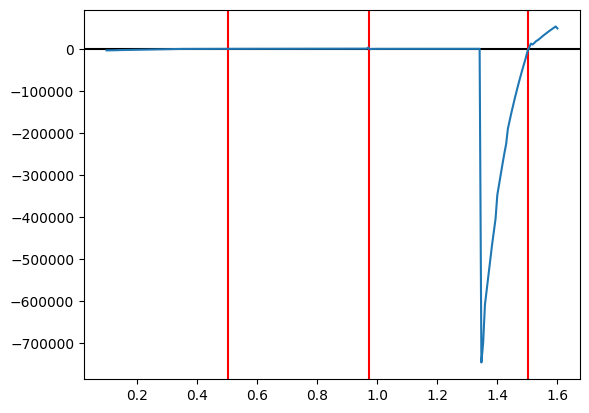

In [34]:
# Repeat the problem setup just for clarity
# physical constants
hbar = 1.0
m    = 1.0
w    = 1.0

# harmonic potential
V = lambda x : m*(w**2)*(x**2) / 2.0

# Integrate until peak from other side:
bounds = [-15.0, 15.0]
dx = 0.01

E_grid = np.linspace(0.1, 1.6, 256)

wronsk_grid = [compute_wronskian(V, bounds, dx, E, m, hbar) for E in tqdm(E_grid)]

fig, ax = plt.subplots()
ax.axhline(0.0, color = 'k')
for idx in range(1, len(wronsk_grid)):
    # Easy check for zero crossing
    if (wronsk_grid[idx - 1] * wronsk_grid[idx]) <= 0:
        spot_guess = 0.5 * (E_grid[idx] + E_grid[idx-1])
        ax.axvline(spot_guess, color = 'r')
        print(f"Bound state near x = {spot_guess:7.5f}")
ax.plot(E_grid, wronsk_grid)

In [35]:
def count_nodes(V, bounds, dx, E, m, hbar):
    x_start, x_end = min(bounds), max(bounds)
    
    # We do not want to stop at the peak, we want the full propagation 
    # to see how many times the wavefunction crosses zero.
    x, psi = numerov_propagate(V, x_start, x_end, dx, E, m, hbar, stop_at_peak=False)
    
    # Count sign changes (where the product of adjacent points is negative)
    nodes = np.sum(psi[:-1] * psi[1:] <= 0)
    
    return nodes

In [36]:
hbar = 1.0
m = 1.0
w = 1.0

# Generate harmonic potential
V = lambda x : m*(w**2)*(x**2) / 2.0

bounds = [-15.0, 15.0]
dx = 0.01

testrange = [1.45, 1.6]

iterations = 32
for idx in range(iterations):
    Etest = 0.5 * (testrange[0] + testrange[1])
    wronsk = compute_wronskian(V, bounds, dx, Etest, m, hbar)
    if wronsk < 0:
        testrange[0] = Etest
    else:
        testrange[1] = Etest

print(Etest)

1.5041592356399631


In [37]:
ranges = np.logspace(0, 2, 16)

In [38]:
def test_bounds(bound_range):
    bounds = [-15.0, 15.0]
    dx = 0.01

    testrange = [1.45, 1.6]

    iterations = 32
    for idx in range(iterations):
        Etest = 0.5 * (testrange[0] + testrange[1])
        wronsk = compute_wronskian(V, bounds, dx, Etest, m, hbar)
        if wronsk < 0:
            testrange[0] = Etest
        else:
            testrange[1] = Etest

    return np.abs(Etest - 1.5)

In [39]:
ranges = np.logspace(0, 1, 32)
errors = [test_bounds(bound_range) for bound_range in tqdm(ranges)]

100%|██████████| 32/32 [00:14<00:00,  2.28it/s]


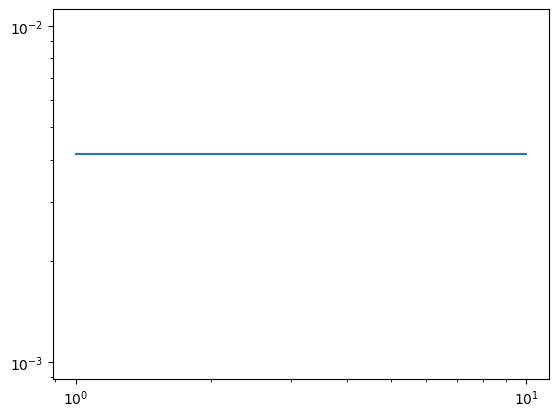

In [40]:
fig, ax = plt.subplots()

ax.plot(ranges, errors)
ax.set_yscale("log")
ax.set_xscale("log")

In [41]:
def test_h(h):
    bounds = [-10.0, 10.0]
    testrange = [1.45, 1.6]

    iterations = 32
    for idx in range(iterations):
        Etest = 0.5 * (testrange[0] + testrange[1])
        wronsk = compute_wronskian(V, bounds, h, Etest, m, hbar)
        if wronsk < 0:
            testrange[0] = Etest
        else:
            testrange[1] = Etest

    return np.abs(Etest - 1.5)

100%|██████████| 16/16 [01:28<00:00,  5.50s/it]


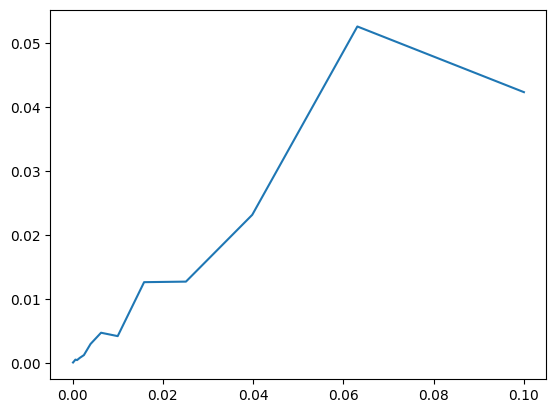

In [43]:
h_matrix = np.logspace(-1, -4, 16)
errors = [test_h(h) for h in tqdm(h_matrix)]

fig, ax = plt.subplots()

ax.plot(h_matrix, errors)